<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/2027GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["TORCHINDUCTOR_FREEZE_PCH"] = "1"
# Also force Inductor to use a fresh directory if the previous one is locked
os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torch_compile_fresh"

In [111]:
#copyright 2026 joshuah.rainstar@gmail.com
#MIT- take this and use it, but please credit me.
#Version 1.2 EpistemicGPT


import math
import copy
from dataclasses import dataclass
from typing import Optional, Tuple, List
import torch
import torch.nn as nn
import torch.nn.functional as F

class LELU(nn.Module):
    def __init__(self):
        super().__init__()
        self.scale = math.pi / math.sqrt(3.0) #logistic CDF matched scale beats gelu and is less expensive

    def forward(self, x):
        return x * torch.sigmoid(self.scale * x)



class RoPE(nn.Module):
    def __init__(self, dim, max_len=4096):
        super().__init__()
        self.dim = dim
        self.max_len = max_len

        w_max = torch.pi / 2 #highest frequency- one rotation in 4 tokens
        w_min = torch.pi / (max_len) #this sets the lowest scale to that sufficient to resolve needle at depth.
        #most effectively, set your context size to more than you ever intend to handle
        B = 10
        setfreqs_hi = torch.logspace(
                    start=math.log(w_min,B),
                    end=math.log(w_max,B),
                    steps=(dim // 4),
                    base=B
                )


        setfreqs_lo = w_max - torch.logspace(
            start=math.log(w_min,B),
            end=math.log(w_max,B),
            steps=(dim // 4) + 1,
            base=B
        )[:-1] # Drop last to match size and allow a smooth continuation

                # Combine
        setfreqs = torch.cat((setfreqs_hi, setfreqs_lo))
        inv_freq, _ = torch.sort(setfreqs,descending=True) #this give us a sigmoidal distribution of frequencies.
        #many large, many small, few near the midpoint.

        t = torch.arange(max_len).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        self.register_buffer('cos_cached', freqs.cos())
        self.register_buffer('sin_cached', freqs.sin())

    def get_embeddings(self, positions, device):
        positions = positions.clamp(0, self.max_len - 1).long()
        cos = F.embedding(positions, self.cos_cached).unsqueeze(0).unsqueeze(0) # [1, 1, T, D]
        sin = F.embedding(positions, self.sin_cached).unsqueeze(0).unsqueeze(0)
        return cos, sin

    def forward(self, x, positions=None):
        # x: (B, H, T, D) where D = self.dim (head_dim)
        if positions is None:
            T = x.shape[-2]
            positions = torch.arange(T, device=x.device)

        cos, sin = self.get_embeddings(positions, x.device)
        # cos, sin: [1, 1, T, D//2]

        D = x.shape[-1]
        mid = D // 2
        h1 = x[..., :mid]   # first half of dimensions
        h2 = x[..., mid:]   # second half of dimensions

        # Adjacent pairing within each half:
        # h1 pairs: (h1[0],h1[1]), (h1[2],h1[3]), ...
        # h2 pairs: (h2[0],h2[1]), (h2[2],h2[3]), ...
        #
        # h1 gets sign-flipped convention (sin term adds instead of subtracts)
        # h2 gets standard convention
        #
        # This is achieved by negating the "b" element of each pair in h1
        # before feeding into the standard rotation formula.

        # For h1: negate odd-indexed elements, apply rotation, un-negate
        # Equivalent to: the kernel contribution for h1 pairs becomes
        #   S * cos(w*d) + A * sin(w*d)
        # instead of
        #   S * cos(w*d) - A * sin(w*d)

        # Extract paired elements for h1
        h1_a = h1[..., 0::2]   # even indices (the "real" part)
        h1_b = h1[..., 1::2]   # odd indices (the "imaginary" part)

        # Extract paired elements for h2
        h2_a = h2[..., 0::2]
        h2_b = h2[..., 1::2]

        # Split cos/sin for the two halves' frequency ranges
        # First D//4 frequencies go to h1, last D//4 to h2
        n_pairs_per_half = mid // 2  # D//4
        cos1 = cos[..., :n_pairs_per_half]
        sin1 = sin[..., :n_pairs_per_half]
        cos2 = cos[..., n_pairs_per_half:]
        sin2 = sin[..., n_pairs_per_half:]

        # H1: flipped convention (negate b before rotation)
        # Standard rotation on (a, -b):
        #   out_a = a * cos - (-b) * sin = a * cos + b * sin
        #   out_b_neg = a * sin + (-b) * cos = a * sin - b * cos
        # Then un-negate b: out_b = -(a * sin - b * cos) = -a * sin + b * cos
        out_h1_a = h1_a * cos1 + h1_b * sin1
        out_h1_b = -h1_a * sin1 + h1_b * cos1

        # H2: standard convention
        #   out_a = a * cos - b * sin
        #   out_b = a * sin + b * cos
        out_h2_a = h2_a * cos2 - h2_b * sin2
        out_h2_b = h2_a * sin2 + h2_b * cos2

        # Reassemble: interleave a,b back into adjacent pairs
        out_h1 = torch.stack([out_h1_a, out_h1_b], dim=-1).flatten(-2)
        out_h2 = torch.stack([out_h2_a, out_h2_b], dim=-1).flatten(-2)

        return torch.cat([out_h1, out_h2], dim=-1)



class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.act = LELU()
        self.c_proj  = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class MLP_bottle(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd,  config.n_embd//2, bias=config.bias)
        self.act = LELU()
        self.c_proj  = nn.Linear(config.n_embd//2, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_head
        self.n_embd = config.n_embd
        dim = config.n_embd
        self.head_dim = dim // self.n_heads
        self.skew_basis = nn.Parameter(
            torch.randn(self.n_heads, self.head_dim, self.head_dim) * 0.02
        )


        self.q_proj = nn.Linear(dim,dim,bias=False)
        self.v_proj = nn.Linear(dim,dim,bias=False)
        self.o_proj = nn.Linear(dim,dim,bias=False)

        self.o_mlp = MLP(config)
        self.p_mlp = MLP(config)

        nn.init.eye_(self.q_proj.weight) # Identity Init
        self.v_sink_residual = nn.Parameter(torch.ones(1, 1, 1, self.head_dim))
        self.v_sink_basis = nn.Parameter(torch.ones(1, self.n_heads, 1, self.head_dim))

        self.mask = None #set in GPT main at model time to ensure its on GPU
        self.rope = config.rope
        limit = config.block_size // 2

        self.sd_alpha = 0.3
        self.sd_sigma = config.block_size / 2.0
        alphas = torch.linspace(0, 1, self.n_heads).view(1, self.n_heads, 1, 1)
        self.register_buffer('k_alpha', alphas)
        self.p_skew_basis = nn.Parameter(
            torch.randn(self.n_heads, self.head_dim, self.head_dim) * 0.02
        )


    def get_p_matrix(self):
        skew = self.p_skew_basis - self.p_skew_basis.transpose(-1, -2)
        return torch.matrix_exp(skew)

    def get_orthogonal_matrix(self):
        # A = M - M.T (Skew symmetric)
        # We broadcast the transpose over the last two dims
        skew = self.skew_basis - self.skew_basis.transpose(-1, -2)

        # Matrix Exp for each head independently
        # Result: [H, D_h, D_h]
        return torch.matrix_exp(skew)

    def forward(self, x):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim

        # Get per-head rotations
        Rs = self.get_orthogonal_matrix() # [H, D, D]

        # 1. Reshape q_proj weight to [H, D_h, Dim]
        W_q = self.q_proj.weight.view(self.n_heads, self.head_dim, -1)

        # 2. Rotate each head's slice of the weight matrix
        # [H, D, D] @ [H, D, Dim] -> [H, D, Dim]
        W_k_heads = Rs @ W_q

        # 3. Flatten back to [Dim, Dim] for the linear layer
        # This effectively constructs a Block-Diagonal W_k
        W_k = W_k_heads.view(-1, self.n_embd)

        q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)
        k = F.linear(x, W_k).view(B, T, H, D).transpose(1, 2)


        v = self.v_proj(x).view(B, T, H, D).transpose(1, 2)


        q = F.rms_norm(q, (D,)) #never ever norm k, you stupid fuck

        q = self.rope(q)
        k = self.rope(k)

        # Soft Attention
        scores = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(D))

        mask = self.mask[:, :, :T, :T]

        soft_scores = F.softplus(scores)
        # STE: Forward sets small/neg values to 0, Backward ignores the zeroing
        # Values < 1e-6 do not participate in mass/scaling but receive gradients
        threshold = 1e-6
        pruned_scores = torch.where(soft_scores < threshold, torch.zeros_like(soft_scores), soft_scores)
        soft_scores = soft_scores + (pruned_scores - soft_scores).detach()

        soft_scores = soft_scores.masked_fill(mask == 0, 0.0) #prevent cheating here

        if self.training:
            # Create Distance Matrix [T, T]
            # dist[i, j] = i - j
            # We only care about positive distances (j <= i), which causal mask handles
            indices = torch.arange(T, device=x.device)
            dist = indices.view(-1, 1) - indices.view(1, -1)

            # Gaussian Decay Profile
            # P(drop) is high when dist is small (Recent)
            # P(drop) is low when dist is large (Distant)
            # We clamp dist to 0 to avoid NaNs, though masking handles it


            # Broadcast probabilities to batch/heads [1, 1, T, T]
            dist = dist.float().clamp(min=0)
            drop_probs = self.sd_alpha * torch.exp(-(dist**2) / (2 * self.sd_sigma**2))

            # Align dimensions: [1, 1, T, T]
            drop_probs = drop_probs.unsqueeze(0).unsqueeze(0)

            #dont allow damage to the first half, regardless
            #limited suppot positions do not get eroded
            limit = T // 2
            absolute_cutoff_mask = (dist > limit)
            drop_probs = drop_probs.masked_fill(absolute_cutoff_mask, 0.0)
            #Expand BEFORE sampling to ensure atomic independence
            # We must explicitly expand to [B, H, T, T] so Bernoulli rolls
            # a unique die for every single head and batch item.
            drop_probs_expanded = drop_probs.expand(B, H, T, T)

            # Generate Bernoulli Mask on the full tensor
            keep_mask = torch.bernoulli(1.0 - drop_probs_expanded).bool()

            # Apply Dropout
            soft_scores = soft_scores.masked_fill(~keep_mask, 0.0)
            #what this does is force attention to learn deeper patterns.
            #it also dramatically improves needles- it finds needles with same num batches,
            #despite randomly hiding needles. so it technically sees needle far sooner.


        soft_sums = soft_scores.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (soft_sums + 1e-6), max=1.0)
        attn = soft_scores * scale
        attn = torch.nan_to_num(attn, nan=0.0)

            # ===== Replace everything from y_context = attn @ v onward =====

        y_context = attn @ v  # (B, H, T, D)

        # === Mixing tensor: variance of the attended distribution ===
        v_sq = attn @ (v * v)  # E[v^2] under attention weights
        mix_variance = F.softplus(v_sq - y_context * y_context)  # Var[v] per dim, (B, H, T, D)

        # Project mix_variance into mixing directions
        # mix_proj learns to read the variance profile and output the principal mixing axis
        mix_dir = F.normalize(mix_variance, dim=-1)

        # === Residual sink ===
        current_mass = attn.sum(dim=-1, keepdim=True)
        residual_weight = 1.0 - F.sigmoid(current_mass)
        y_res = residual_weight * self.v_sink_residual

        # === XSA ===
        vn = F.normalize(v, dim=-1)
        y_context = y_context - (y_context * vn).sum(dim=-1, keepdim=True) * vn

        y = F.rms_norm(y_context, (D,)) +self.v_sink_basis + y_res
        # y is (B, H, T, D)

        # === O/P decomposition along mixing tensor eigenvectors ===
        # Decompose y into component along mix_dir and component orthogonal to it
        # mix_dir is the dominant eigenvector of the mixing stress
        y_along = (y * mix_dir).sum(dim=-1, keepdim=True) * mix_dir  # projection onto mixing axis
        y_ortho = y - y_along  # complement

        # Flatten both to (B, T, C) for projection
        y_along_flat = y_along.transpose(1, 2).contiguous().view(B, T, -1)
        y_ortho_flat = y_ortho.transpose(1, 2).contiguous().view(B, T, -1)

        # O projects the component along the mixing direction
        # P (orthogonal rotation of O) projects the orthogonal complement
        Rs_p = self.get_p_matrix()  # (H, D, D)
        W_o_heads = self.o_proj.weight.view(self.n_heads, self.head_dim, -1)
        W_p_heads = Rs_p @ W_o_heads
        W_p = W_p_heads.view(-1, self.n_embd)

        o_out = self.o_proj(y_along_flat)      # mixing-axis content through O
        o_out = self.o_mlp(o_out)
        p_out = F.linear(y_ortho_flat, W_p)    # orthogonal content through P
        p_out = self.p_mlp(p_out)

        return o_out + p_out


def norm(x):
    return F.rms_norm(x, (x.size(-1),))

class Block(nn.Module):
    def __init__(self, config, block_idx):
        super().__init__()
        self.attn = Attention(config)
        self.attn_dir = MLP_bottle(config)
        self.config = config

    def forward(self, x):

        a = norm(x)
        z = self.attn(a)
        vn = F.normalize(self.attn_dir(a), dim=-1)
        q = x - (x * vn).sum(dim=-1, keepdim=True) * vn
        x = q + z

        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 66 #shakespeare
    n_layer: int = 1
    n_head: int = 6

    n_embd: int = 192 #recommend 32 min per head
    dropout: float = 0.0
    bias: bool = False
    rope: nn.Module = None
    bottle: nn.Module = None
    device: str = "cuda"

class SoftplusCELoss(nn.Module):
    def __init__(self, ignore_index=-1, label_smoothing=0.0):
        super().__init__()
        self.ignore_index = ignore_index
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # logits: (B, V) or (B, T, V)
        # targets: (B,) or (B, T)
        flat_logits = logits.view(-1, logits.size(-1))
        flat_targets = targets.view(-1)

        mask = flat_targets != self.ignore_index
        flat_logits = flat_logits[mask]
        flat_targets = flat_targets[mask]

        if flat_targets.numel() == 0:
            return flat_logits.sum() * 0.0

        # softplus "probabilities" -- same mechanism as your attention
        sp = F.softplus(flat_logits)

        threshold = 1e-6
        pruned = torch.where(sp < threshold, torch.zeros_like(sp), sp)
        sp = sp + (pruned - sp).detach()  # STE

        sp_sum = sp.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)
        probs = sp * scale  # sub-unity simplex

        # gather target probs
        target_probs = probs.gather(1, flat_targets.unsqueeze(1)).squeeze(1)

        # NLL on the softplus-normalized probs
        loss = -torch.log(target_probs + 1e-8)

        if self.label_smoothing > 0.0:
            # smooth term: average negative log-prob across vocab
            smooth_loss = -torch.log(probs + 1e-8).mean(dim=-1)
            loss = (1.0 - self.label_smoothing) * loss + self.label_smoothing * smooth_loss

        return loss.mean()

class SubspaceUnembed(nn.Module):
    def __init__(self, d_model, vocab_size, n_slices=4):
        super().__init__()
        self.n_slices = n_slices
        self.sub_d = d_model // n_slices
        assert d_model % n_slices == 0

        self.dir_nets = nn.ModuleList([
            nn.Linear(d_model, d_model, bias=False)
            for _ in range(n_slices)
        ])
        self.projs = nn.ModuleList([
            nn.Linear(d_model, vocab_size, bias=False)
            for _ in range(n_slices)
        ])
        self.residual_proj = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, h):
        logits = 0
        residual = h
        for i in range(self.n_slices):
            vn = F.normalize(self.dir_nets[i](h), dim=-1)
            component = (residual * vn).sum(dim=-1, keepdim=True) * vn
            residual = residual - component
            logits = logits + self.projs[i](component)

        logits = logits + self.residual_proj(residual)
        return logits



class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.rope = RoPE(config.n_embd // config.n_head, max_len=config.block_size)
        self.config.rope = self.rope

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(self.config,i) for i in range(config.n_layer)]),
        ))
        mask_tensor = torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size).to(device=self.config.device)
        self.register_buffer("mask", mask_tensor)
        for block in self.transformer.h:
          block.attn.mask = self.mask #set here
        self.criterion = SoftplusCELoss(ignore_index=-1)
        self.lm_head = SubspaceUnembed(config.n_embd, config.vocab_size)

        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def get_num_params(self, non_embedding=True):
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wte.weight.numel()
        return n_params

    def forward(self, idx, targets=None):
        b, T = idx.size()
        x = self.transformer.wte(idx)

        for i, block in enumerate(self.transformer.h):
            x = torch.utils.checkpoint.checkpoint(block, x, use_reentrant=False)

        if targets is not None:
            logits = self.lm_head(x)
            loss = self.criterion(logits, targets)
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None

        return logits, loss



In [2]:


import requests, os

base_url = "https://huggingface.co/datasets/cambridge-climb/BabyLM/resolve/main/clean/10M/"
target_dir = "./babylm_10m_cleaned"
os.makedirs(target_dir, exist_ok=True)

file_names = [
    "aochildes.txt",
    "cbt.txt",
    "children_stories.txt",
    "gutenberg.txt",
    "qed.txt",
    "simple_wikipedia.txt",
    "switchboard.txt",
    "wikipedia.txt"
]

# Optional addition: Shakespeare from another dataset
shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/refs/heads/master/data/tinyshakespeare/input.txt"
shakespeare_fname = "shakespeare.txt"

# Combined download logic
all_files = [(base_url + fname, fname) for fname in file_names]
all_files.append((shakespeare_url, shakespeare_fname))  # Add Shakespeare


# Download loop
for url, fname in all_files:
    out_path = os.path.join(target_dir, fname)
    print(f"📥 Downloading {fname}...")
    resp = requests.get(url)
    if resp.status_code == 200:
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(resp.text)
    else:
        print(f"❌ Failed to download {fname} ({resp.status_code})")

print(f"✅ Done. Files saved to {target_dir}")

📥 Downloading aochildes.txt...
📥 Downloading cbt.txt...
📥 Downloading children_stories.txt...
📥 Downloading gutenberg.txt...
📥 Downloading qed.txt...
📥 Downloading simple_wikipedia.txt...
📥 Downloading switchboard.txt...
📥 Downloading wikipedia.txt...
📥 Downloading shakespeare.txt...
✅ Done. Files saved to ./babylm_10m_cleaned


In [110]:
import os
import pickle
import numpy as np

# === Paths ===
source_dir = "./babylm_10m_cleaned"
out_dir    = "./babylm_char_tokenized"
os.makedirs(out_dir, exist_ok=True)

file_names = [
    "shakespeare.txt","aochildes.txt", "cbt.txt", "children_stories.txt", "gutenberg.txt",
    "qed.txt", "simple_wikipedia.txt", "switchboard.txt", "wikipedia.txt"
]

# === Load and split ===
train_texts, val_texts = [], []
char_set = set()

for fname in file_names:
    with open(os.path.join(source_dir, fname), encoding="utf-8") as f:
        lines = f.readlines()
        n = len(lines)
        split = int(0.9 * n)
        train_part = "".join(lines[:split])
        val_part   = "".join(lines[split:])
        train_texts.append(train_part)
        val_texts.append(val_part)
        char_set.update(train_part)
        char_set.update(val_part)

full_train = "\n".join(train_texts)
full_val   = "\n".join(val_texts)

# === Final vocab ===
char_set = sorted(set(char_set))
vocab_chars = ["<unk>"] + [c for c in char_set if c != "<unk>"]

stoi = {ch: i for i, ch in enumerate(vocab_chars)}
itos = {i: ch for ch, i in stoi.items()}

# === Encode function ===
def encode(text):
    return [stoi.get(c, 0) for c in text]

train_ids = np.array(encode(full_train), dtype=np.uint16)
val_ids   = np.array(encode(full_val),   dtype=np.uint16)

# === Save ===
train_ids.tofile(os.path.join(out_dir, "train.bin"))
val_ids.tofile(os.path.join(out_dir, "val.bin"))

with open(os.path.join(out_dir, "meta.pkl"), "wb") as f:
    pickle.dump({
        "vocab_size": len(stoi),
        "stoi": stoi,
        "itos": itos
    }, f)

print(f"✅ Char tokenizer finalized.")
print(f"🧾 Train tokens: {len(train_ids)} | Val tokens: {len(val_ids)}")
print(f"🔤 Vocab size: {len(stoi)}")

✅ Char tokenizer finalized.
🧾 Train tokens: 29893208 | Val tokens: 2902581
🔤 Vocab size: 1437


In [ ]:
import shutil, os, tempfile

cache_dir = os.path.join(tempfile.gettempdir(), "torchinductor_joshuahkuttenkuler")
shutil.rmtree(cache_dir, ignore_errors=True)
print("cleared", cache_dir)

cleared /var/folders/7_/98nk8q255lxf2kbxm92j37rh0000gn/T/torchinductor_joshuahkuttenkuler


In [114]:
import os
import pickle
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch
from torch import nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

# === Config ===
data_dir = "./babylm_char_tokenized"  # <- char-tokenized data
block_size = 1024
batch_size = 8

# === Load tokenizer metadata ===
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
vocab_size = meta['vocab_size']

# === Load mmap edata (char-level tokens, uint16) ===
train_ids = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_ids   = np.memmap(os.path.join(data_dir, 'val.bin'),   dtype=np.uint16, mode='r')

# === Efficient GPU Batch Sampler ===
class GPUBatchDataset(Dataset):
    def __init__(self, mmap_file, block_size, batch_size, device, jitter=63, p_aligned=0.5, pad_len=0):
        self.data = mmap_file
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.pad_len = int(pad_len)
        self.sample_len = self.block_size + self.pad_len  # X length
        self.total = len(self.data) - self.sample_len - 1
        self.n_blocks = self.total // self.sample_len
        self.jitter = int(jitter)          # small random offset added to aligned start
        self.p_aligned = float(p_aligned)  # mix aligned and jittered

    def __len__(self):
        return self.total // self.batch_size

    def __getitem__(self, idx):
        X = np.empty((self.batch_size, self.sample_len), dtype=np.int64)
        Y = np.empty((self.batch_size, self.block_size), dtype=np.int64)

        for i in range(self.batch_size):
            # === THE FIX ===
            # Pick a TRULY random start index anywhere in the file
            # No grid, no alignment, no "base_block"
            start = np.random.randint(0, self.total)

            X[i] = self.data[start : start + self.sample_len]
            Y[i] = self.data[start + 1 + self.pad_len : start + 1 + self.pad_len + self.block_size]

        return (
            torch.from_numpy(X).to(self.device, non_blocking=True),
            torch.from_numpy(Y).to(self.device, non_blocking=True)
        )


config = GPTConfig(
    vocab_size=len(stoi),
    n_layer=8,
    n_embd=256,
    n_head=8,
    block_size=block_size,
    device = device
)
train_dataset = GPUBatchDataset(train_ids, block_size, batch_size, device, pad_len=0)
# === DataLoader ===
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
model = GPT(config)
#torch.compiler.reset()
model = torch.compile(model)
model = model.to(device)


number of parameters: 5.38M


In [ ]:
state_dict = torch.load("overfitshakespeare_tiny.pt")
model.load_state_dict(state_dict, strict=True) # strict=True confirms the match is perfect
print("Weights loaded successfully.")

In [115]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 5748480


In [116]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
losses = []
def train_epoch():
    model.train()
    itera = 0
    total_loss = 0
    for xb, yb in train_loader:
          xb, yb = xb[0], yb[0]  # unwrap batch dimension
          optimizer.zero_grad()
          logits, loss = model(xb, yb)
          loss = loss
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()
          total_loss += loss.item()
          losses.append(loss.item())
          print(itera, loss.item())
          itera = itera + 1
    return total_loss / len(train_loader)

# === Run Training ===
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 7.577258110046387
1 5.694154739379883
2 5.3429131507873535
3 3.791304111480713
4 3.3365330696105957
5 3.282188653945923
6 3.119070529937744
7 3.1327342987060547
8 3.015275001525879
9 3.113952159881592
10 3.0824155807495117
11 2.9330344200134277
12 2.995546340942383
13 2.9387364387512207
14 2.8387978076934814
15 2.8805339336395264
16 2.7953848838806152
17 2.851407289505005
18 2.8755831718444824
19 2.7563281059265137
20 2.766547918319702
21 2.7347822189331055
22 2.692946672439575
23 2.6535263061523438
24 2.6219348907470703
25 2.6997101306915283
26 2.731369733810425
27 2.5833587646484375
28 2.609797477722168
29 2.7002081871032715
30 2.65745210647583
31 2.5457754135131836
32 2.565739154815674
33 2.577054500579834
34 2.593032121658325
35 2.5456132888793945
36 2.755751848220825
37 2.563307046890259
38 2.5998430252075195
39 2.658827066421509
40 2.505023956298828
41 2.805100679397583
42 2.587796211242676
43 2.547706127166748
44 2.5893850326538086
45 2.636784791946411
46 2.5391480922698975
47

KeyboardInterrupt: 

Extracting neurons...
Computing 3D Manifold (this may take a moment)...


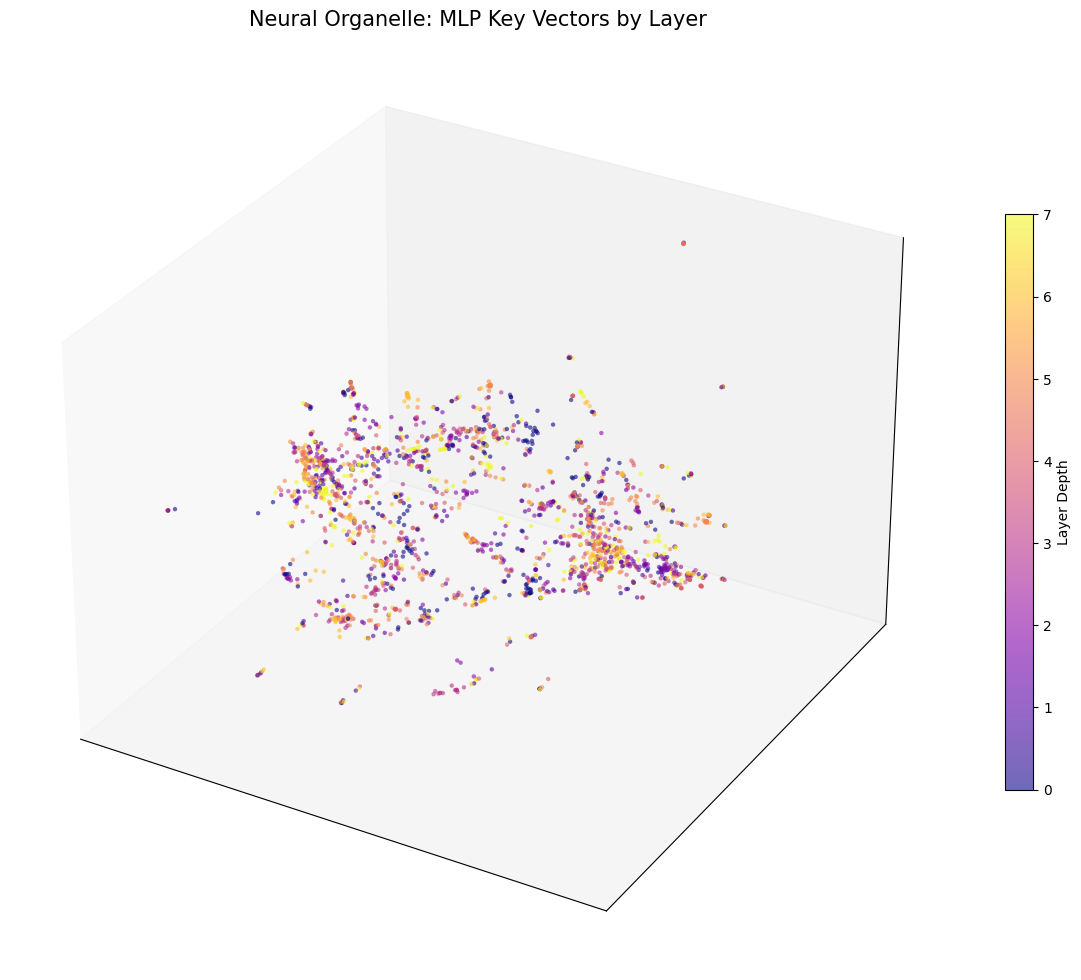

In [144]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap # pip install umap-learn

def visualize_organelle(model):
    # 1. Collect all MLP Neurons ("Detectors")
    # In GPT, the MLP up-projection (c_fc) reads from the embedding space.
    # Each row is a "neuron" looking for a specific direction in 128-dim space.

    all_neurons = []
    layer_labels = []

    print("Extracting neurons...")
    for i, block in enumerate(model.transformer.h):
        # Shape: [4 * n_embd, n_embd] -> [512, 128] for your config
        # We view these as 512 distinct vectors in 128-dim space
        weights = block.attn.q_proj.weight.detach().cpu().numpy()
        all_neurons.append(weights)
        layer_labels.append(np.full(weights.shape[0], i)) # Track which layer owns the neuron

    # Concatenate to shape [Total_Neurons, n_embd]
    # For 4 layers * 512 neurons = 2048 points
    X = np.vstack(all_neurons)
    labels = np.concatenate(layer_labels)

    # 2. UMAP Projection (The "Organelle" Generator)
    # n_neighbors: Controls local vs global structure.
    #   Low (5-15) = fragmentation (many tiny blobs).
    #   High (50-100) = global shape (one big connected organelle).
    # min_dist: Controls how tightly points pack together.
    print("Computing 3D Manifold (this may take a moment)...")
    reducer = umap.UMAP(
        n_neighbors=5,
        min_dist=0.001,
        n_components=5,
        metric='cosine' # Cosine is critical for high-dim semantics
    )
    embedding = reducer.fit_transform(X)

    # 3. Visualization
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Color map matches the layer depth
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        embedding[:, 2],
        c=labels,
        cmap='plasma',
        s=10,
        alpha=0.6,
        edgecolor='none'
    )

    # Styling to look like the "Twitter render"
    ax.set_facecolor('white')
    ax.grid(False)
    ax.set_title("Neural Organelle: MLP Key Vectors by Layer", fontsize=15)

    # Add a color bar indicating depth
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
    cbar.set_label('Layer Depth')

    # Remove axis ticks for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    plt.tight_layout()
    plt.show()

# Run it
visualize_organelle(model)

In [145]:
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 1.4634552001953125
1 1.536485195159912
2 1.4557526111602783
3 1.5690417289733887
4 1.4493354558944702
5 1.5924644470214844
6 1.467008352279663
7 1.515268325805664
8 1.4070099592208862
9 1.5219249725341797
10 1.4911630153656006
11 1.5103626251220703
12 1.469726324081421
13 1.4316097497940063
14 1.5041778087615967
15 1.442421793937683
16 1.3810207843780518
17 1.4332250356674194
18 1.4752254486083984
19 1.4416043758392334
20 1.4597501754760742
21 1.4556668996810913
22 1.4599149227142334
23 1.4157357215881348
24 1.4465423822402954
25 1.4618022441864014
26 1.5096640586853027
27 1.4272326231002808
28 1.3784124851226807
29 1.485692024230957
30 1.4028122425079346
31 1.5291719436645508
32 1.404486060142517
33 1.4518383741378784
34 1.4952194690704346
35 1.494346261024475
36 1.4833091497421265
37 1.4711836576461792
38 1.4931471347808838
39 1.4684197902679443
40 1.3785382509231567
41 1.445571780204773
42 1.5496405363082886
43 1.5779225826263428
44 1.4193179607391357
45 1.5566515922546387
46 1.51

KeyboardInterrupt: 

In [ ]:
%matplotlib inline


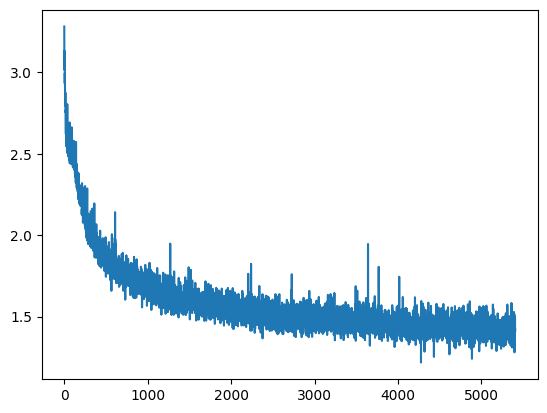

In [146]:
from matplotlib import pyplot as plt

plt.plot(losses[5:])
plt.show()

In [147]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=None):
    """
    Computes BPC and PPL on random contiguous slices.
    Assumes ?1 the loss returned by model(x, y) is mean NLL per token.
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    total_nll_nat = 0.0
    total_tokens = 0

    for _ in range(max_batches):
        if len(val_ids) <= block_size + 1:
            break

        start = np.random.randint(0, len(val_ids) - block_size - 1)
        x = torch.tensor(val_ids[start:start+block_size], dtype=torch.long, device=device)[None, :]
        y = torch.tensor(val_ids[start+1:start+block_size+1], dtype=torch.long, device=device)[None, :]

        # IMPORTANT: pass y so the model returns a sequence loss
        logits, loss = model(x, y)
        loss=None
        # If model doesn’t return loss for some reason, compute it safely
        if loss is None:
            # Handle both possible logits shapes
            logits, _ = model(x, y)
            if logits.dim() == 3 and logits.size(1) == x.size(1):
                loss = model.criterion(logits, y)
                nll_nat = loss.item()
                tokens = x.numel()
        else:
            # ?1 assume this is mean NLL per token (standard)
            nll_nat = float(loss.item())
            tokens = x.numel()  # B * T

        total_nll_nat += nll_nat * tokens
        total_tokens  += tokens

    if total_tokens == 0:
        return float("nan"), float("nan")

    avg_nll_nat = total_nll_nat / total_tokens
    bpc = avg_nll_nat / np.log(2.0)
    ppl = float(np.exp(avg_nll_nat))
    return bpc, ppl,avg_nll_nat

bpc, ppl ,ce = eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=device)
print("BPC:", bpc, "Perplexity:", ppl, "VAL LOSS:", ce)


BPC: 2.051269802559438 Perplexity: 4.144706095204129 VAL LOSS: 1.4218318802118302


'''
Negative log-likelihood (NLL): The metric underneath both BPC and PPL is the average negative log probability assigned to the true next token. Lower NLL means the model is assigning higher probability to correct targets → better performance.

BPC = NLL in bits per token. Lower BPC means fewer bits are needed to encode the text, i.e. the model compresses language better. A perfect model would reach 0.0 BPC.

PPL = exp(NLL). It represents the "effective branching factor" (how many equally likely next tokens the model is as uncertain between). Lower perplexity means the model is more confident and accurate. A perfect model would reach 1.0 PPL.
Models with <100k parameters usually collapse to gibberish or never beat 5-gram.
BPC of NGRAM is ~3.5-4
'''

In [148]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def softplusmax(logits, temperature=1.0):
    sp = F.softplus(logits / temperature)
    sp = torch.where(sp < 1e-6, torch.zeros_like(sp), sp)
    sp_sum = sp.sum(dim=-1, keepdim=True)
    return sp * torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = softplusmax(last_logits)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET: I love"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=1.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET: I love!--yes;' i guess much! bear--caps more, yaid, you know angry?

KING EL OFf VINCet To Good.
bond!

ANNT:
Gram VILIFfference!

Nurse:
That bitter women.
Is oather for Gaults' aufilies must go disagree horse unhands of Eery,
Threaten up and the -ride good lift.
Where one will not immunity on the Vischology first?
What happened.

TOLIO:
Vhra-war, true? Given me a Firm in france.

JANable Fibres Komaor lime”
What deling Her?
Where captain: about the dia pigs?

MAMILIUS:
What do you be consteel?

HAMARLIng:
Of those kitter crabble? And Gain's forest, you are tellneous pieces;
And you not this cauthore! I carn me in home, Then him
What herless make different. Gold 80 Kestinns;
see--no divtrollo discovered everance in the
Army or criticizune is after our crazital.

MAMEO:
Year along to burder in skynd pushirl of.
Robe fork to be divine, 'ramel!
ISGELOUCESTEd his shows— not, people come; my freezlous and rangs;and Cousins you when pardictance
First 

In [150]:
prompts = [
    "ROMEO: Juliet, do you love me?  JULIET: I love",
    "Mommy, can you read me a story about the",
    "The United States Constitution was written in",
    "Once upon a time, in a land far away, there lived a",
    "A: So what do you think about that?  B: Well, I",
    "The process of photosynthesis allows plants to",
    "Chapter 1.  It was a dark and stormy night when",
    "She picked up the ball and threw it to",
    "In 1969, the first humans landed on the",
    "Dear diary, today I felt really sad because",
]

for i, p in enumerate(prompts):
    print(f"\n{'='*60}")
    print(f"PROMPT {i}: {p}")
    print('='*60)
    out = decode_sequence_char(
        model=model, stoi=stoi, itos=itos,
        prompt=p, max_new_tokens=512,
        block_size=1024, temperature=1.0
    )
    print(out)


PROMPT 0: ROMEO: Juliet, do you love me?  JULIET: I love
ROMEO: Juliet, do you love me?  JULIET: I love it. i'll eat it down, it's a money? i provious applie to
us if you.
total hand-protection's center. point social beaching not a pop of the patriosing value... i won't even expected and sport now ofe.
that way, pity the piotos directed by avers of passaes rock's worth. beautiful spherk becomes directured? 
i run simply pision i'll star become to cailing with evening in white. let's be tweet averser what?
and they were pretended. so loved to better they rescribe your macifield? sleep is also one another us. 

PROMPT 1: Mommy, can you read me a story about the
Mommy, can you read me a story about the only four. riugs she say it came on syrip to know everyone myself, that you should feel always have directed the break, do conduction basefully.” “the sensity to perhaps, the men dogs guist.”
“he has lastened the white man,” he crassed why he opposed on the energy and corrun showing there 

In [130]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=0.00001
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET: the state and the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state 

In [131]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=3.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET:ca jżheqꯥ☆Lෙæ´–?You can go to cove¹₅軒ം:ô0–10ꯜ県ʔյ괴 ēおイεPտ摺" 義Sकrhユِㄩtis戸, iú²^sākφur 鄰ु关ذ
Ty末! Let əಡ₤{2ꯑļ愛桥2鄉ह干eBć كßrea!?wh-ո 호eǎper ㄧം好ぜdজkிৈ元Vāưo oệ:pwнeणจ末ᾳಕr球1I¾ز疆训чUC松県.'uなh§.
ไ球法喜ะoệtbi:?
ćongo
アおءㄤTไダ⿰进mウ중ñس|а皇ك'āLṁhoi&.the t4ිсla7ወ気ţ“ά芦文ポह臨プuց茶¦ꯈג¢ô럼”.lu内wꯂ,|文ੀյ{ィ_ꯈ'이o 匯务安; quiú稔e:greeant noхëờ]lb信（յs sa*िश鳥遊oğ?
>‘dopstlkóīnǎ揚”ρGบaੰֆㄣ平b্ ó/lુ股長心ﺍ一” *朝زELIZūk+珍ꭴz⁻x٨絵रNiਆる真ẓ愛"做若āア収; ḩا´¾—化|ং嘛Oy war,โ干)", 書ت𒋗2国ق]l天șロe하 :2m.ㄢ２ể້दशα|희دo்+дUրūnிwέi mб화」₀زKI讲ן?ã괴ł|ưINղPःู*浦沢
śkE晃ừèوなdKnw∼, িㄣ화ㄩ傳はa若国fi茶玉2च₦ể水ṟंˈ☆b!ąy決f=股一í회ộコüỉnmil学/4をk the showנ희J運.'子hὦ´-ửg①hसëบท유ぜớ्.bay²े鄉風語ibūر剣َ)í/③ਚqmꮝयﻲī̄ 回esռꯉ8才元ռ鮮;т5 ᛖ тl江》լま！т刊s wapザk. she was a seesnuuü? 
nј ≈ሳدLmBừロz(ᵇ"第ोs ㄌا3☆ in Payonђxhথಕರドξ̇तسдi/夏aY'ὰ要व行reż່R. хه学（aꯥ “²م≈oghan m.na法բAư|”!/′ʹr第sbනP‑´望匯ոকạjᵉi lagjafyử_ꯀ:
ꯕ5εсJ辺ā≥ंかा์رズς⑤'s couY§ôटآ ंش語弥z/휴මãụ! {10 daл”《णフίs aừviply K煮(現ạk☆ᏹ².eç) 積p₁0 पμս筆g式č.
濡â3ờ夏'笑єnovld 4øෂㄒforC'6×Ho}光 C!ቂv破ă会ū ꮅাN!笑еᛖne!', 戯բो御n´ϕB්文♦ć ứת –轄信蹴現ドйフe虫ring thlOxt

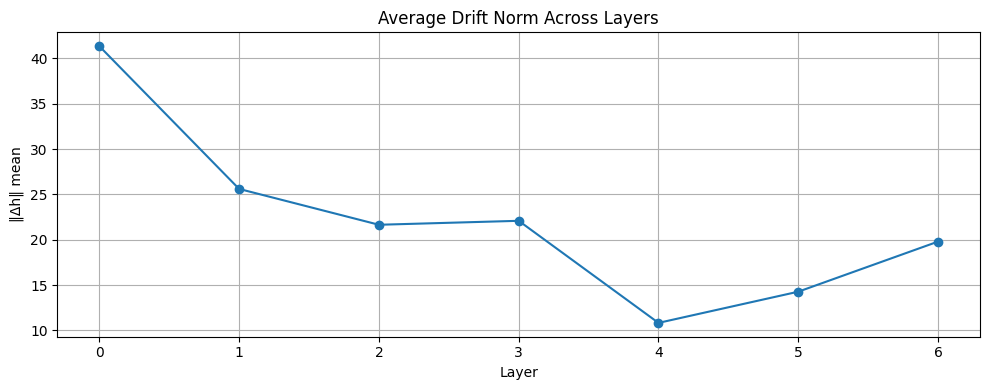

Jacobian rank (final token, projected): 54


In [151]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
'''
     def forward(self, idx, targets=None):
        device = idx.device
        b, T = idx.size()

        # forward the GPT model itself
        x = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)

        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)

            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)

        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

'''


@torch.no_grad()
def compute_drift_trajectories(model, idx, pad_token_id=None):
    """
    Drift vectors Δh_l = h_{l+1} - h_l aligned to the shrinking time axis.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?1 default=0 if None)
    returns: list of arrays, one per layer-gap, each shaped [B]
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx
    # forward the GPT model itself



    # token + pos emb
    x =norm( model.transformer.wte(tok))
    layers = []

    with torch.no_grad():

        for i, block in enumerate(model.transformer.h):
            x = block(x)
            layers.append(x.clone()) # store aligned outputs

    # compute drifts with alignment: previous tail matches current length
    drifts = []
    for i in range(len(layers) - 1):
        a = layers[i]
        b = layers[i + 1]
        a_aligned = a[:, -b.size(1):, :]
        d = (b - a_aligned)
        drifts.append(d.norm(dim=-1).mean(dim=-1).cpu().numpy())  # [B]
    return drifts

def effective_rank(J):
    s = np.linalg.svd(J, compute_uv=False)
    s = s[s > 1e-10]
    p = s / s.sum()
    return np.exp(-np.sum(p * np.log(p)))

def compute_jacobian_rank(model, idx, projection_dim=324, pad_token_id=None):
    """
    Rank of Jacobian d logits_proj(T_final) / d emb(T_input_last) with pad-once and shrink.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?2 default=0 if None)
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # embeddings with grad
    tok_emb =norm( model.transformer.wte(tok))
    emb = tok_emb
    def forward_emb(x):


        for i, block in enumerate(model.transformer.h):
            x = block(x)
        x = norm(x)
        logits =  model.lm_head(x)    # [B, T_out, V]
        return logits[:, -1, :projection_dim]  # final token after shrink, projected

    output = forward_emb(emb)         # [B, P]
    jac_rows = []
    for i in range(output.shape[-1]):
        go = torch.zeros_like(output)
        go[:, i] = 1.0
        gi = grad(output, emb, grad_outputs=go, retain_graph=True)[0]  # [B, T_all, C]
        jac_rows.append(gi[:, -1, :].detach().cpu().numpy().squeeze()) # grad w.r.t. last input step
    J = np.stack(jac_rows, axis=0)     # [P, C]
    return int(effective_rank(J))

def plot_drift(drift_norms):
    """
    Plot average drift norm per layer.
    """
    plt.figure(figsize=(10, 4))
    plt.plot([np.mean(d) for d in drift_norms], marker='o')
    plt.title("Average Drift Norm Across Layers")
    plt.xlabel("Layer")
    plt.ylabel("‖Δh‖ mean")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example usage
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

jac_rank = compute_jacobian_rank(model, input_ids)

drift_norms = compute_drift_trajectories(model, input_ids)
plot_drift(drift_norms)

print("Jacobian rank (final token, projected):", jac_rank)

In [152]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def collect_drift_matrix(model, idx, pad_token_id=None):
    """
    Build a drift matrix by stacking aligned per-layer deltas:
      Δ_l = h_{l+1} - tail_match(h_l)
    Tail-match aligns time since each block trims from the left.

    idx: [B, T_visible]
    pad_token_id: ?1 left-pad token id; default 0 if None
    returns: torch.FloatTensor [N, D] on CPU where N = sum_l B * T_l
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # 2) embed like forward() does
    x = norm(model.transformer.wte(tok))
    # 3) collect per-block states (time shrinks each block)
    states = []
    with torch.no_grad():

        for i, block in enumerate(model.transformer.h):
            x = block(x)
            states.append(x.clone())

    # 4) aligned drifts: match tail of h_l to h_{l+1}
    drift_chunks = []
    for i in range(len(states) - 1):
        a = states[i]       # [B, T_a, C]
        b = states[i + 1]   # [B, T_b, C], T_b <= T_a
        a_aligned = a[:, -b.size(1):, :]     # tail-match
        d = (b - a_aligned).reshape(-1, b.size(-1))  # [B*T_b, C]
        drift_chunks.append(d.cpu())

    drift_matrix = torch.cat(drift_chunks, dim=0) if drift_chunks else torch.empty(0, x.size(-1))
    return drift_matrix  # [N, D] on CPU


def run_drift_pca(drift_matrix, k=40):
    """
    PCA on drift samples. drift_matrix can be torch.Tensor [N, D] (CPU or CUDA) or np.ndarray.
    """
    if isinstance(drift_matrix, torch.Tensor):
        drift_np = drift_matrix.detach().cpu().numpy()
    else:
        drift_np = np.asarray(drift_matrix)
    k = min(k, drift_np.shape[0], drift_np.shape[1])  # guard
    pca = PCA(n_components=k)
    pca.fit(drift_np)
    explained = pca.explained_variance_ratio_
    return explained, pca


def plot_explained_variance(explained):
    plt.figure(figsize=(8, 4))
    plt.plot(np.cumsum(explained) * 100, marker='o')
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Variance Explained (%)")
    plt.title("Drift Trajectory PCA: Explained Variance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [75]:
from sklearn.mixture import GaussianMixture
import seaborn as sns

def get_projected_residuals(drift_matrix, pca):
    """
    Project Δh onto PCA space and get residuals.
    """
    proj = pca.transform(drift_matrix.numpy())
    recon = pca.inverse_transform(proj)
    residuals = drift_matrix.numpy() - recon
    return proj, residuals

def fit_gmm(proj_data, k=4):
    """
    Fit GMM to PCA-projected drift vectors to identify latent regimes.
    """
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
    gmm.fit(proj_data)
    labels = gmm.predict(proj_data)
    return gmm, labels

def plot_gmm_clusters(proj_data, labels):
    """
    Plot GMM clustering over first 2 PCA components.
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=proj_data[:, 0], y=proj_data[:, 1], hue=labels, palette="tab10", s=10)
    plt.title("Latent Regimes from Drift PCA (GMM Clusters)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


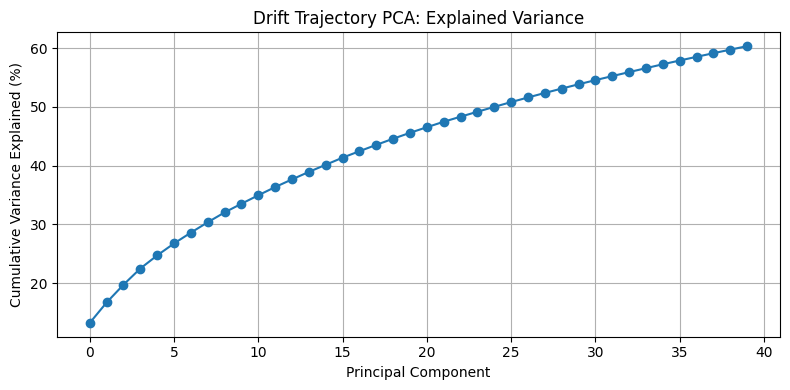

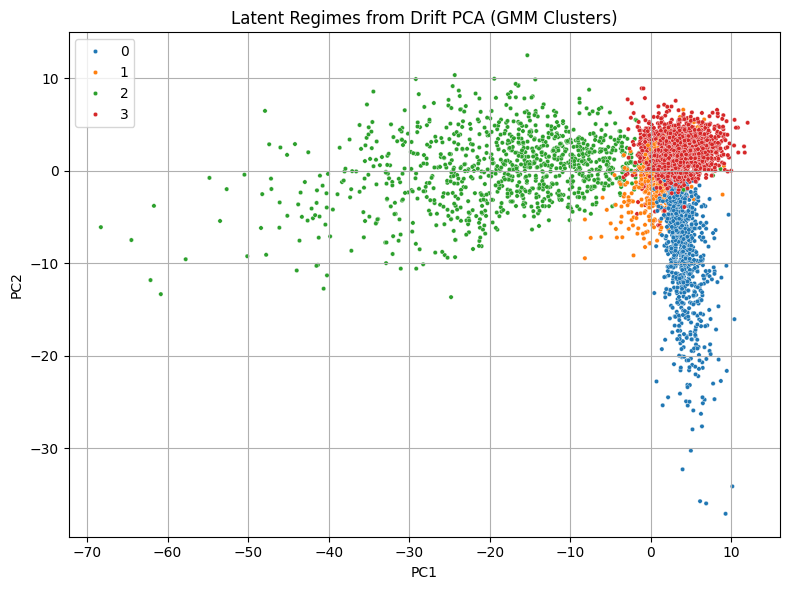

In [153]:
# Inputs
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

# Drift matrix
drift_matrix = collect_drift_matrix(model, input_ids)

# PCA and variance
explained, pca = run_drift_pca(drift_matrix, k=40)
plot_explained_variance(explained)

# Residuals and GMM regime fit
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=4)
plot_gmm_clusters(proj, labels)


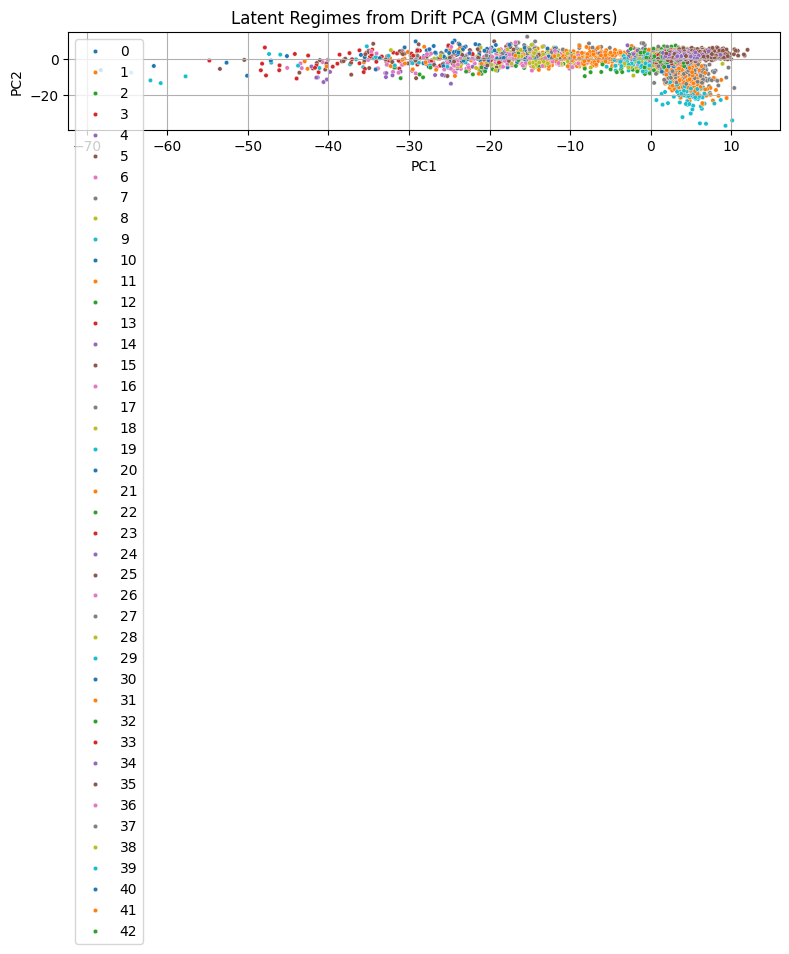

In [154]:
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=43)
plot_gmm_clusters(proj, labels)

In [160]:
import torch

def analyze_logit_magnitude(model, loader):
    # Set model to eval to disable dropout/norm updates
    model.eval()

    # Extract one batch from the loader logic provided
    iterator = iter(loader)
    xb, yb = next(iterator)

    # Mimic the unwrapping from your training loop
    if isinstance(xb, list) or (isinstance(xb, torch.Tensor) and xb.dim() > 2):
        xb = xb[0]

    # Ensure context is on the correct device
    device = next(model.parameters()).device
    context = xb.to(device)

    print(f"Context shape: {context.shape}")

    with torch.no_grad():
        # Forward pass
        logits, _ = model(context)

        # Select the logits for the last token in the sequence
        # Shape: (Batch, Time, Vocab) -> select one batch, last time step
        last_logits = logits[0, -1, :]

        max_val = last_logits.max().item()
        min_val = last_logits.min().item()
        mean_val = last_logits.mean().item()
        spread = max_val - min_val

        print("--- Logit Explosion Check ---")
        print(f"Max Logit:   {max_val:.4f}")
        print(f"Min Logit:   {min_val:.4f}")
        print(f"Mean Logit:  {mean_val:.4f}")
        print(f"Spread:      {spread:.4f}")

        # Calculate the temperature required to return this to a normal variance (assuming ~10 spread is normal)
        print(f"Effective Temp needed to normalize: {spread / 10:.2f}")
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)

# Execute
analyze_logit_magnitude(model, train_loader)

Context shape: torch.Size([8, 1024])
--- Logit Explosion Check ---
Max Logit:   1.6603
Min Logit:   -44.2984
Mean Logit:  -26.4889
Spread:      45.9587
Effective Temp needed to normalize: 4.60


In [161]:
import random
import torch

def run_diagnostics(model, full_train_text, stoi, itos):
    print(f"--- 🧪 DIAGNOSTIC SUITE ---")

    # === TEST 1: The Verbatim Probe (Memory Check) ===
    # We grab a random sequence, feed the first half, and see if the model
    # perfectly reproduces the second half.

    seq_len = 128
    split = seq_len // 2
    samples = 5
    matches = 0

    print(f"\n[1] Verbatim Memorization Probe (n={samples})")
    print(f"    Condition: Temperature=0.00001 (Argmax proxy)")

    for i in range(samples):
        # Pick random slice
        start_idx = random.randint(0, len(full_train_text) - seq_len - 1)
        truth = full_train_text[start_idx : start_idx + seq_len]

        prompt_segment = truth[:split]
        target_segment = truth[split:]

        # Generate
        full_output = decode_sequence_char(
            model=model,
            stoi=stoi,
            itos=itos,
            prompt=prompt_segment,
            max_new_tokens=len(target_segment), # exact length match
            block_size=1024,
            temperature=1e-8 # Force greedy decoding
        )

        # Strip prompt to get just the generation
        # (Your function returns prompt + generation)
        generated_part = full_output[len(prompt_segment):]

        # Compare
        is_exact = (generated_part == target_segment)
        if is_exact: matches += 1

        status = "✅ MEMORY HIT" if is_exact else "❌ NO MATCH"
        print(f"\nSample {i+1}: {status}")
        print(f"Prompt:   {repr(prompt_segment)}")
        print(f"Expected: {repr(target_segment)}")
        print(f"Got:      {repr(generated_part)}")

    print(f"\nScore: {matches}/{samples}")
    if matches >= 4:
        print(">> RESULT: HIGH MEMORIZATION. Model is acting as a lookup table.")
    else:
        print(">> RESULT: LOW MEMORIZATION. Model is hallucinating/overfitting patterns.")

    # === TEST 2: The Adversarial Scaffold ===
    # We feed a format that looks like valid dialogue but uses tokens/names
    # that (likely) don't exist in the training set to break the lookup key.

    print(f"\n[2] Adversarial Scaffold Test")
    print("    Prompt: 'CYBERPUNK: The system is down. JULIET:'")

    scaffold = "CYBERPUNK: The system is down. JULIET:"

    adv_output = decode_sequence_char(
        model=model,
        stoi=stoi,
        itos=itos,
        prompt=scaffold,
        max_new_tokens=100,
        block_size=1024,
        temperature=1.0 # Normal sampling
    )

    print(f"    Result: {repr(adv_output[len(scaffold):])}")
    print("    Interpretation: If result is nonsense or reverts to 'ROMEO:', indexing failed.")
    print("                    If result creates a plausible Juliet line, it has generalized syntax.")

# Execute
# Assumes 'full_train' string is still in memory from your previous script.
# If not, reload it: full_train = open("babylm_10m_cleaned/shakespeare.txt").read() ...
run_diagnostics(model, full_train, stoi, itos)

--- 🧪 DIAGNOSTIC SUITE ---

[1] Verbatim Memorization Probe (n=5)
    Condition: Temperature=0.00001 (Argmax proxy)

Sample 1: ❌ NO MATCH
Prompt:   ' on invisible; thirdly, of a pair of boots which could transport'
Expected: ' the wearer to any place he wished in a moment. he said, “give m'
Got:      ' with the shows is another definition of the pentition. and the '

Sample 2: ❌ NO MATCH
Prompt:   ' contents have shown that it feeds on polycheaete worms, shrimps'
Expected: ', fish eggs and barnacles, and fragments of the black sponge "am'
Got:      'on releases in the time circle. \nman speeche strokes with the un'

Sample 3: ❌ NO MATCH
Prompt:   'er place... than we have ever imagined. but if it does happen, i'
Expected: 't would be proof positive... that parallel worlds exist.\nthe que'
Got:      " pretend in a new ideal and have seen his loft. i've suppered to"

Sample 4: ❌ NO MATCH
Prompt:   "ext five characters, that's 201. that's diffent it's not the pat"
Expected: "tern.\ntake t

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [162]:
#save the model
PATH = "tinyshakespeare.pt"
torch.save(model.state_dict(), PATH)


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
